<a href="https://colab.research.google.com/github/AqsaAamena/Basic-Python-Projects/blob/main/Assignment_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. (Data Loading & Initial Analysis)
Load the Ford Car Dataset using pandas.
Display the first 10 rows and last 5 rows.
Check the shape (number of rows and columns) and data types of all
columns.
Write observations about the dataset structure in comments.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#loads the dataset
data=pd.read_csv('ford_car_dataset.csv')
#display first 10 rows of dataset
print("First 10 rows")
print(data.head(10))

#display last 5 rows of dataset
print("\nLast 5 rows")
print(data.tail())

#check shape of dataset
print("\nShape of dataset:-")
print(data.shape)

#check data types of all columns
print("\nData types of all columns:-")
print(data.dtypes)


# --- Dataset Observations ---
# 1. The dataset contains 17,966 rows (records) and 9 columns (features).
# 2. It contains a mix of categorical/text data ('model', 'transmission', 'fuelType')
#    and numerical data ('year', 'price', 'mileage', 'tax', 'mpg', 'engineSize')
# 3. Datatypes of all the columns displayed infront of columns name



First 10 rows
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

Last 5 rows
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    

Q2. (Missing & Duplicate Values)
Perform a detailed check on the dataset:
Find the total number of missing values in each column.
Identify and remove duplicate rows if any.
Write a summary of your findings and how you handled them in comments.

In [19]:
#Missing values in each column
missing_values_count = data.isnull().sum()
print("Missing values in each columns:-")
print(missing_values_count)

#Duplicate rows in dataset
duplicate_rows = data[data.duplicated()]
num_duplicates = len(duplicate_rows)
if any(duplicate_rows):
    print(f"\nDuplicate rows found in dataset: {num_duplicates}")
    # Use inplace=True to actually save the changes to 'data'
    data.drop_duplicates(inplace=True)
    print("Duplicate rows removed from dataset.")
else:
    print("\nNo duplicate rows found in dataset.")
print("\nNew shape of dataset after removing duplicate rows")
print(data.shape)

# --- Q2 Summary of Findings ---
# 1. Missing Values: Found 0 missing values across all columns.
# 2. Duplicate Rows: Found 154 duplicate rows. Handled by permanently removing them using drop_duplicates().
# 3. Final dataset shape was successfully reduced from 17,966 to 17,812 rows.


Missing values in each columns:-
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate rows found in dataset: 0
Duplicate rows removed from dataset.

New shape of dataset after removing duplicate rows
(17812, 9)


Q3. (Statistical Summary)
Generate the statistical summary of all numeric columns using describe().
Identify minimum, maximum, mean, and median values for key columns like
price, mileage, and year.

In [21]:
#Find numerical columns
numerical_columns = data.select_dtypes(include=['number'])
print("Numerical columns:")
print(numerical_columns.columns.tolist())
#Statistical summary of numerical columns
print("\nStatistical summary of numerical columns:")
numerical_columns.describe()

# key columns like price, mileage, and year
# 1. YEAR: Range is from 1996 to 2060. The median (50%) year is 2017.
#    *Note: The max year of 2060 appears to be an incorrect data entry
# 2. PRICE: Average (mean) car price is 12,269.56, ranging from a minimum of £495 to a maximum of 54,995.
#    The median price is £11,288.
# 3. MILEAGE: Average mileage is ~23,381 miles, with a median of 18,277 miles.
#    The maximum mileage recorded is 177,644 miles.

Numerical columns:
['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

Statistical summary of numerical columns:


,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


Q4. (Histogram of Numeric Features)
Plot histograms for all important numeric columns (price, mileage, year,
engineSize, mpg).
Analyze the distribution for each feature and note your findings in comments.

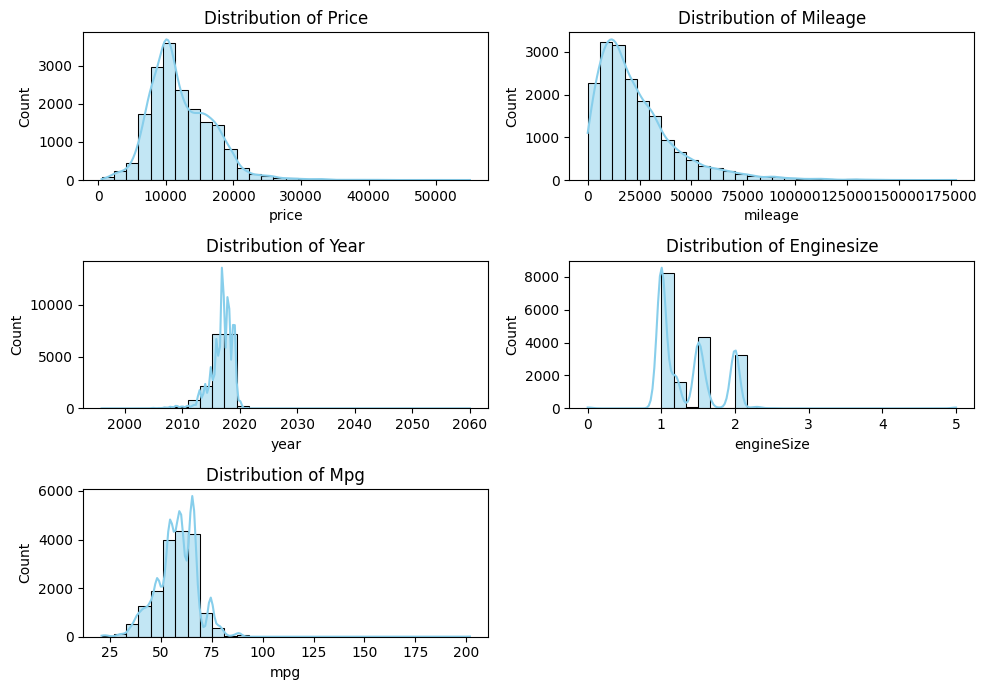

In [30]:
# List of columns to plot
columns_to_plot = ['price', 'mileage', 'year', 'engineSize', 'mpg']

# Set up the matplotlib figure size
plt.figure(figsize=(10, 7))

# Loop through each column and create a subplot
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col)
    plt.ylabel('Count')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

# --- Analysis of Distributions ---
# 1. Price: Right-skewed. Most cars are priced between 8,000 and 15,000, with a few expensive luxury/performance models pulling the tail to the right.
# 2. Mileage: Highly right-skewed. The vast majority of cars have low mileage (under 40,000 miles), which is typical for a modern used car dataset.
# 3. Year: Highly left-skewed. Most cars are from recent years (2016-2019). The data contains a clear extreme outlier at the year 2060.
# 4. EngineSize: Multi-modal/Discrete peaks. Most cars have small, fuel-efficient engines around 1.0, 1.5, or 2.0 liters.
# 5. MPG: Mostly normally distributed around 50-60 mpg, but shows a few extreme outlier vehicles with exceptionally high mpg ratings.

Q5. (Count Plots of Categorical Features)
Create count plots for all categorical columns (fuelType, transmission, model, etc.)
using seaborn.
Analyze which categories are most common.
Write insights about market trends based on these plots in comments.

/tmp/ipykernel_1710/2634059344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='fuelType', order=data['fuelType'].value_counts().index, palette='viridis')
/tmp/ipykernel_1710/2634059344.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='transmission', order=data['transmission'].value_counts().index, palette='viridis')


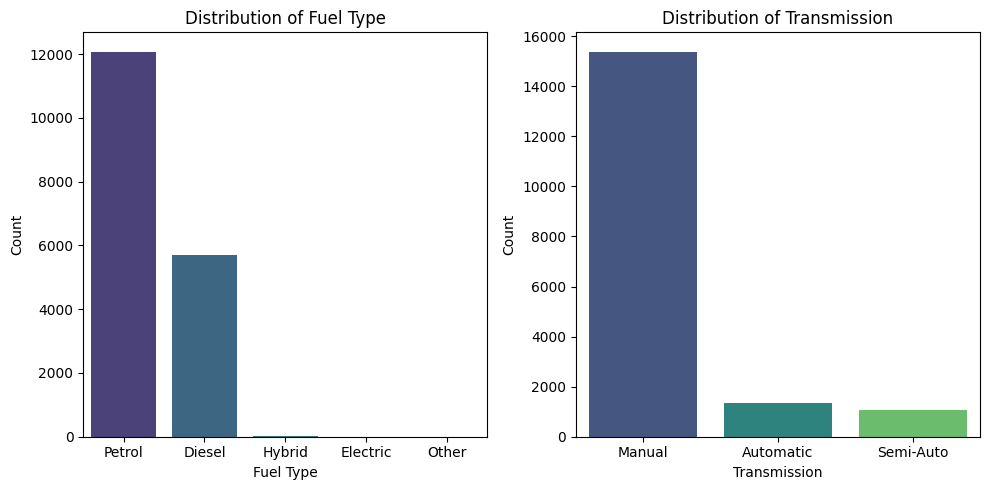

/tmp/ipykernel_1710/2634059344.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='model', order=top_models, palette='magma')


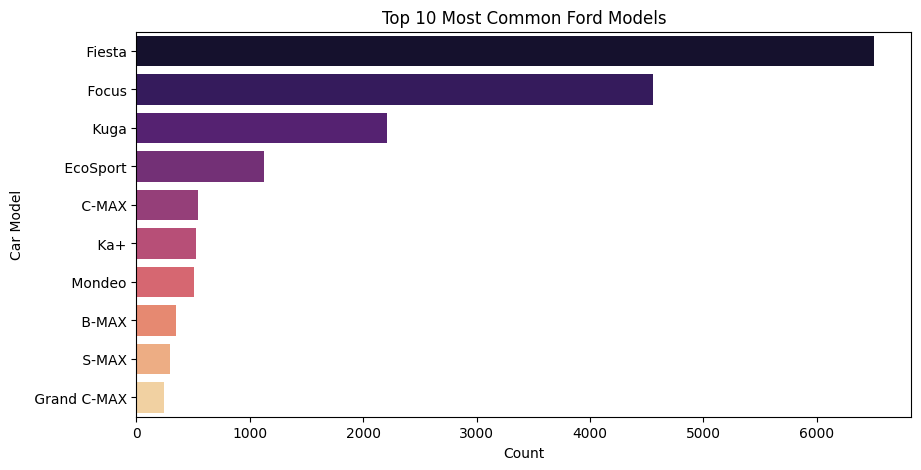

In [33]:
# List of categorical columns to plot
categorical_cols = ['fuelType', 'transmission']

# Set up the figure for fuelType and transmission
plt.figure(figsize=(10, 5))

# 1. Plot for fuelType
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='fuelType', order=data['fuelType'].value_counts().index, palette='viridis')
plt.title('Distribution of Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')

# 2. Plot for transmission
plt.subplot(1, 2, 2)
sns.countplot(data=data, x='transmission', order=data['transmission'].value_counts().index, palette='viridis')
plt.title('Distribution of Transmission')
plt.xlabel('Transmission')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 3. Separate plot for Top 10 Car Models (to keep it readable)
plt.figure(figsize=(10, 5))
top_models = data['model'].value_counts().head(10).index
sns.countplot(data=data, y='model', order=top_models, palette='magma')
plt.title('Top 10 Most Common Ford Models')
plt.xlabel('Count')
plt.ylabel('Car Model')

plt.show()

# --- Q5 Market Trend Insights ---
# 1. Fuel Type: Petrol is overwhelmingly the most common fuel type in this dataset, closely followed by Diesel.
# 2. Transmission: Manual transmissions are significantly more popular than Automatic or Semi-Automatic options.
# 3. Models: The 'Fiesta' and 'Focus' are by far the clear market leaders in volume.

Q6. (Correlation Heatmap)
Create a heatmap of the correlation matrix for numeric features.
Use seaborn with proper annotations.
Identify which features are highly correlated with the target variable (price).
Write your observations in comment.

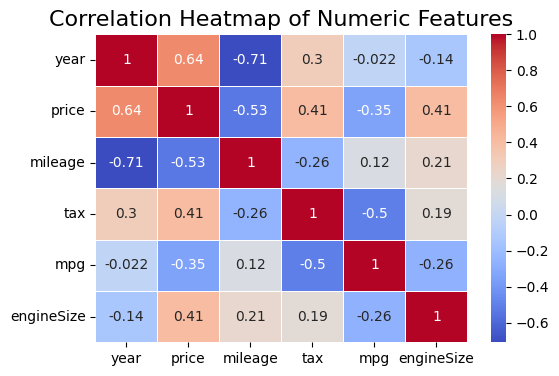

In [36]:
# Compute the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=['number']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(6, 4))

# Create the heatmap with annotations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Add title and show the plot
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

# --- Q6 Correlation Observations ---
# 1. Highest Positive Correlation: 'year' has a strong positive correlation with 'price' (~0.64).
# 2. Highest Negative Correlation: 'mileage' has a strong negative correlation with 'price' (~ -0.53).
# 3. Moderate Correlation: 'engineSize' shows a moderate positive correlation with 'price' (~0.41).
# 4. Weak/Negative Correlation: 'mpg' has a negative correlation with 'price' (~ -0.34) .

Q8. (Encoding Categorical Variables)
Convert all categorical columns into numeric form using appropriate encoding
techniques:
Use One Hot Encoding.
Show before and after transformation for at least 2 columns.

In [54]:
# Select columns to display before encoding
columns_to_show = ['transmission', 'fuelType']
print("--- BEFORE One-Hot Encoding (Sample Rows) ---")
print(data[columns_to_show].head(5))

# Apply One-Hot Encoding to all categorical columns
data_encoded = pd.get_dummies(data, columns=['transmission', 'fuelType'])

# Identify the newly created encoded columns for our sample features
encoded_cols_sample = [col for col in data_encoded.columns if 'transmission_' in col or 'fuelType_' in col]

print("\n--- AFTER One-Hot Encoding ---")
print(data_encoded[encoded_cols_sample].head(5))

# Print final shape to see the expanded features
print(f"\nNew dataset shape after One-Hot Encoding: {data_encoded.shape}")

--- BEFORE One-Hot Encoding (Sample Rows) ---
  transmission fuelType
0    Automatic   Petrol
1       Manual   Petrol
2       Manual   Petrol
3       Manual   Petrol
4    Automatic   Petrol

--- AFTER One-Hot Encoding ---
   transmission_Automatic  transmission_Manual  transmission_Semi-Auto  \
0                    True                False                   False   
1                   False                 True                   False   
2                   False                 True                   False   
3                   False                 True                   False   
4                    True                False                   False   

   fuelType_Diesel  fuelType_Electric  fuelType_Hybrid  fuelType_Other  \
0            False              False            False           False   
1            False              False            False           False   
2            False              False            False           False   
3            False              False

Q9. (Feature Scaling)
Apply Standard Scaling (using StandardScaler from sklearn) on the numeric
independent features.
Show the first 5 rows of scaled data.

In [55]:
from sklearn.preprocessing import StandardScaler

# 1. Identify the numeric independent features (exclude 'price')
numeric_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit and transform the independent features
# We create a copy of the dataframe to avoid modifying the original data_encoded directly
data_scaled = data_encoded.copy()
data_scaled[numeric_features] = scaler.fit_transform(data_encoded[numeric_features])

# 4. Show the first 5 rows of the scaled data (just the scaled features for clarity)
print("--- First 5 Rows of Scaled Independent Features ---")
print(data_scaled[numeric_features].head(5))


--- First 5 Rows of Scaled Independent Features ---
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


Q10. (Mini Project - Complete Preprocessing Pipeline)
Create a complete preprocessing pipeline for the Ford Car Dataset:
1. Load and clean the data (handle missing & duplicate values).
2. Perform EDA (histograms + count plots + heatmap).
3. Identify input and output features.
4. Encode categorical variables.
5. Scale the numeric features.

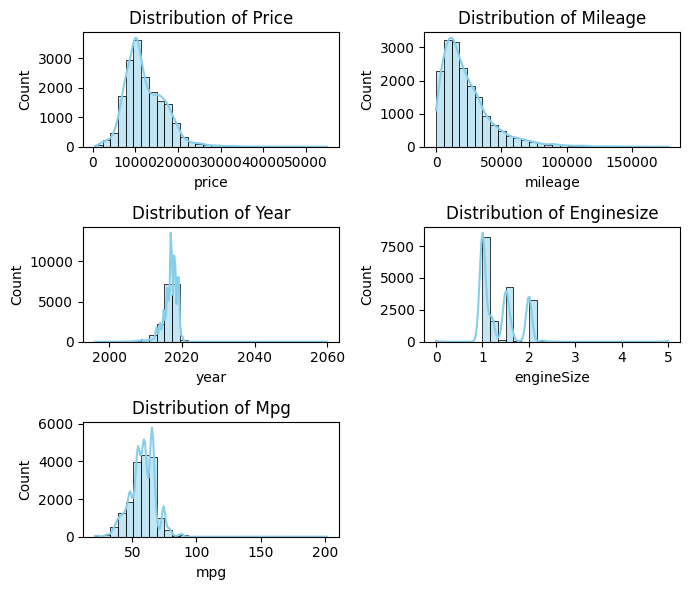

/tmp/ipykernel_1710/2800340093.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pipeline, x='fuelType', order=df_pipeline['fuelType'].value_counts().index, palette='viridis')
/tmp/ipykernel_1710/2800340093.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pipeline, x='transmission', order=df_pipeline['transmission'].value_counts().index, palette='viridis')


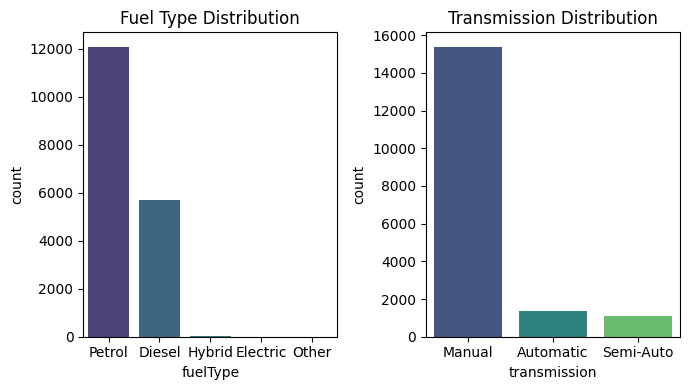

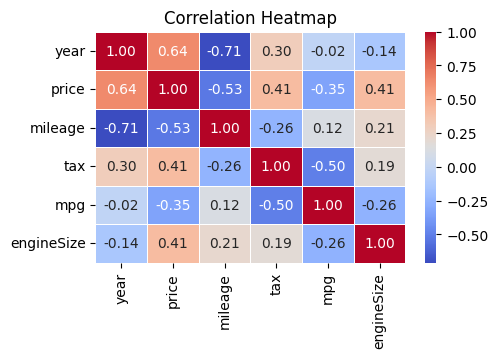


--- Final Preprocessed Pipeline Dataset (First 5 Rows) ---
       year  price   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059  12000 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393  14000 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059  13000 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726  17500 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726  16500 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0            False        False          False  ...                   False   
1            False        False          False  ...                   False   
2            False        False          False  ...                   False   
3            False        False          False  ...                   False   
4            False        False          False  ...                   False 

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# STEP 1: Load and Clean the Data
# Load
df_pipeline = pd.read_csv('ford_car_dataset.csv')

# Handle duplicates permanently
df_pipeline.drop_duplicates(inplace=True)

# STEP 2: EDA (Exploratory Data Analysis)
# 2a. Histograms for Numeric Features
columns_to_plot = ['price', 'mileage', 'year', 'engineSize', 'mpg']
plt.figure(figsize=(7, 6))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_pipeline[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
plt.tight_layout()
plt.show()

# 2b. Count Plots for Categorical Features
plt.figure(figsize=(7, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=df_pipeline, x='fuelType', order=df_pipeline['fuelType'].value_counts().index, palette='viridis')
plt.title('Fuel Type Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df_pipeline, x='transmission', order=df_pipeline['transmission'].value_counts().index, palette='viridis')
plt.title('Transmission Distribution')
plt.tight_layout()
plt.show()

# 2c. Correlation Heatmap
print()
plt.figure(figsize=(5, 3))
numeric_cols = df_pipeline.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# STEP 3: Identify Input and Output Features
# Output (Target): price
# Inputs (Independent): All other remaining columns

# STEP 4: Encode Categorical Variables
# One-hot encoding the categorical variables
df_pipeline_encoded = pd.get_dummies(df_pipeline, columns=['model', 'transmission', 'fuelType'], drop_first=True)

# STEP 5: Scale the Numeric Features
numeric_independent = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
df_pipeline_encoded[numeric_independent] = scaler.fit_transform(df_pipeline_encoded[numeric_independent])

# Display the final preprocessed snapshot
print("\n--- Final Preprocessed Pipeline Dataset (First 5 Rows) ---")
print(df_pipeline_encoded.head(5))
print(f"\nFinal pipeline shape: {df_pipeline_encoded.shape}")